# Encoding Categorical Features

Most machine learning algorithms work exclusively with numbers. Categorical columns must be converted into numeric representations — but the *way* you encode them matters: the wrong choice imposes a false numerical relationship between categories, or explodes the feature space unnecessarily.

### What you will learn

| Section | Encoding | Best for |
|---------|----------|----------|
| 1 | Ordinal encoding | Categories with a natural order (small < medium < large) |
| 2 | One-hot encoding | Nominal categories with low cardinality (≤ ~15 values) |
| 3 | Target encoding | High-cardinality columns; tree models |
| 4 | Frequency encoding | High-cardinality; when label is unavailable |
| 5 | Comparison and leakage prevention | Picking the right encoder and fitting it correctly |

**Dataset:** Ames Housing (via `sklearn`) — rich with categorical features of varying cardinality and order.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 110

print('Setup complete.')

Setup complete.


In [2]:
# Load Ames Housing dataset
from sklearn.datasets import fetch_openml
housing = fetch_openml(name='house_prices', as_frame=True, parser='auto')
df = housing.frame.copy()

# Keep a manageable subset of columns for demonstration
cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'Neighborhood',
        'ExterQual', 'BsmtQual', 'KitchenQual', 'GarageType',
        'SaleType', 'MSZoning', 'LotShape']
df = df[cols].copy()

# Convert target to float
df['SalePrice'] = pd.to_numeric(df['SalePrice'], errors='coerce')
df = df.dropna(subset=['SalePrice'])

print(f'Shape: {df.shape}')
print('\nCategorical columns and their cardinality:')
for col in df.select_dtypes('object').columns:
    print(f'  {col:15s}  {df[col].nunique():3d} unique values')

Shape: (1460, 11)

Categorical columns and their cardinality:
  Neighborhood      25 unique values
  ExterQual          4 unique values
  BsmtQual           4 unique values
  KitchenQual        4 unique values
  GarageType         6 unique values
  SaleType           9 unique values
  MSZoning           5 unique values
  LotShape           4 unique values


---
## Section 1 — Ordinal Encoding

Use ordinal encoding when categories have a **meaningful, known order**. Assigning integers `0, 1, 2, ...` preserves the rank relationship that algorithms can exploit.

**Never** use ordinal encoding on nominal categories (e.g. color, city) — the arbitrary integers imply a distance relationship that does not exist.

**Examples of genuinely ordinal columns:**
- Quality ratings: `Po < Fa < TA < Gd < Ex`
- Size tiers: `Small < Medium < Large`
- Education level, income bracket, severity score

In [3]:
# ExterQual, BsmtQual, KitchenQual use the same 5-level scale
quality_order = ['Po', 'Fa', 'TA', 'Gd', 'Ex']  # worst → best

print('Unique ExterQual values in data:')
print(df['ExterQual'].value_counts().sort_index())

Unique ExterQual values in data:
ExterQual
Ex     52
Fa     14
Gd    488
TA    906
Name: count, dtype: int64


In [4]:
# Define the encoder with explicit category order
ordinal_enc = OrdinalEncoder(
    categories=[quality_order, quality_order, quality_order],
    handle_unknown='use_encoded_value',
    unknown_value=-1,
)

quality_cols = ['ExterQual', 'BsmtQual', 'KitchenQual']
df_qual = df[quality_cols].fillna('TA')  # fill missing with typical

encoded = ordinal_enc.fit_transform(df_qual)
df_ordinal = pd.DataFrame(encoded, columns=[c + '_ord' for c in quality_cols])

print('Original vs encoded (first 8 rows):')
result = pd.concat([df_qual.reset_index(drop=True), df_ordinal], axis=1)
print(result.head(8))

Original vs encoded (first 8 rows):
  ExterQual BsmtQual KitchenQual  ExterQual_ord  BsmtQual_ord  KitchenQual_ord
0        Gd       Gd          Gd            3.0           3.0              3.0
1        TA       Gd          TA            2.0           3.0              2.0
2        Gd       Gd          Gd            3.0           3.0              3.0
3        TA       TA          Gd            2.0           2.0              3.0
4        Gd       Gd          Gd            3.0           3.0              3.0
5        TA       Gd          TA            2.0           3.0              2.0
6        Gd       Ex          Gd            3.0           4.0              3.0
7        TA       Gd          TA            2.0           3.0              2.0


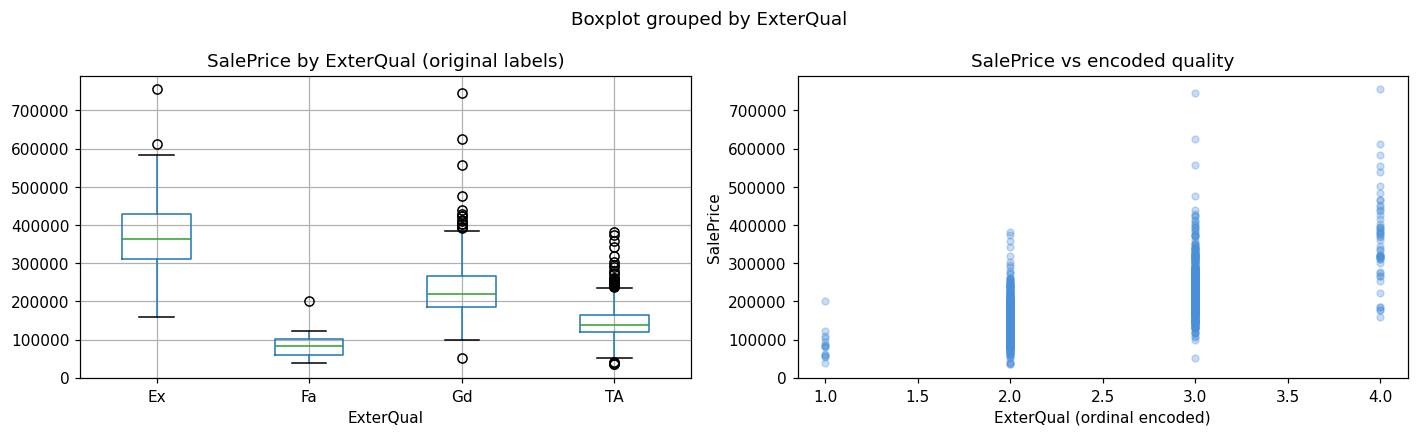

In [5]:
# Visualise: does the ordinal encoding correlate with sale price?
df_plot = df[['SalePrice', 'ExterQual']].copy()
df_plot['ExterQual_ord'] = ordinal_enc.transform(
    df_plot[['ExterQual']].fillna('TA').values.reshape(-1, 1).repeat(3, axis=1)
)[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Box plots by original label
order = [q for q in quality_order if q in df_plot['ExterQual'].unique()]
df_plot.boxplot(column='SalePrice', by='ExterQual', ax=axes[0])
axes[0].set_title('SalePrice by ExterQual (original labels)')
axes[0].set_xlabel('ExterQual')

# Scatter of encoded value vs price
axes[1].scatter(df_plot['ExterQual_ord'], df_plot['SalePrice'],
                alpha=0.3, s=20, color='#4a90d9')
axes[1].set_xlabel('ExterQual (ordinal encoded)')
axes[1].set_ylabel('SalePrice')
axes[1].set_title('SalePrice vs encoded quality')

plt.tight_layout()
plt.show()

---
## Section 2 — One-Hot Encoding

For **nominal** categories (no inherent order), one-hot encoding creates a binary column per category. The algorithm sees no implied distance between categories.

**When to use:**
- Linear models and neural networks (which assume numeric distances)
- Low-cardinality columns (< ~15 unique values)
- When interpretability of individual feature weights matters

**The dummy variable trap:** With *k* categories, you need only *k−1* columns — the last is perfectly predicted by the others. Drop one with `drop='first'` or `drop='if_binary'` to avoid multicollinearity in linear models. Tree-based models are immune and can use all *k*.

In [6]:
# MSZoning: 5 nominal categories — good OHE candidate
print('MSZoning value counts:')
print(df['MSZoning'].value_counts())

MSZoning value counts:
MSZoning
RL           1151
RM            218
FV             65
RH             16
'C (all)'      10
Name: count, dtype: int64


In [7]:
# --- sklearn OneHotEncoder ---
ohe = OneHotEncoder(
    drop='first',            # avoid dummy variable trap
    sparse_output=False,     # return dense array
    handle_unknown='ignore', # unseen categories → all zeros (safe for deployment)
)

zoning_clean = df[['MSZoning']].fillna('RL')
ohe_encoded = ohe.fit_transform(zoning_clean)
df_ohe = pd.DataFrame(ohe_encoded, columns=ohe.get_feature_names_out())

print('One-hot encoded MSZoning (first 8 rows):')
print(pd.concat([zoning_clean.reset_index(drop=True), df_ohe], axis=1).head(8))

One-hot encoded MSZoning (first 8 rows):
  MSZoning  MSZoning_FV  MSZoning_RH  MSZoning_RL  MSZoning_RM
0       RL          0.0          0.0          1.0          0.0
1       RL          0.0          0.0          1.0          0.0
2       RL          0.0          0.0          1.0          0.0
3       RL          0.0          0.0          1.0          0.0
4       RL          0.0          0.0          1.0          0.0
5       RL          0.0          0.0          1.0          0.0
6       RL          0.0          0.0          1.0          0.0
7       RL          0.0          0.0          1.0          0.0


In [8]:
# --- pandas get_dummies: quick OHE for exploration ---
# Useful for notebooks but harder to apply correctly to train/test splits
df_dummies = pd.get_dummies(df[['MSZoning', 'LotShape']], drop_first=True, dtype=int)
print('pd.get_dummies result:')
print(df_dummies.head(5))
print(f'\nColumns created: {df_dummies.columns.tolist()}')

pd.get_dummies result:
   MSZoning_FV  MSZoning_RH  MSZoning_RL  MSZoning_RM  LotShape_IR2  \
0            0            0            1            0             0   
1            0            0            1            0             0   
2            0            0            1            0             0   
3            0            0            1            0             0   
4            0            0            1            0             0   

   LotShape_IR3  LotShape_Reg  
0             0             1  
1             0             1  
2             0             0  
3             0             0  
4             0             0  

Columns created: ['MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'LotShape_IR2', 'LotShape_IR3', 'LotShape_Reg']


In [9]:
# --- High-cardinality OHE: the feature explosion problem ---
print('Neighborhood unique values:', df['Neighborhood'].nunique())

ohe_neighborhood = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
neighborhood_encoded = ohe_neighborhood.fit_transform(df[['Neighborhood']].fillna('NAmes'))
print(f'One-hot encoding adds {neighborhood_encoded.shape[1]} columns for Neighborhood')
print('→ At 25 unique values, OHE is still manageable; beyond ~50, prefer target encoding')

Neighborhood unique values: 25
One-hot encoding adds 25 columns for Neighborhood
→ At 25 unique values, OHE is still manageable; beyond ~50, prefer target encoding


---
## Section 3 — Target Encoding

Target encoding replaces each category with a **statistic of the target variable** for that category (typically the mean). It handles high cardinality gracefully and gives tree models a compact, informative numeric feature.

**The leakage risk:** If you compute target means on the full dataset and use them in training, the model sees target information during fit → optimistic evaluation. Always compute target encoding **within cross-validation folds** or use **leave-one-out** encoding.

We implement a simple but correct cross-fold target encoder below.

In [10]:
def target_encode_cv(
    train: pd.DataFrame,
    col: str,
    target: str,
    n_splits: int = 5,
    smoothing: float = 10.0,
    random_state: int = 42,
) -> pd.Series:
    """
    Cross-fold target encoding with smoothing.

    smoothing: strength of the global mean prior.
               Higher values shrink rare-category estimates toward the global mean.
    """
    global_mean = train[target].mean()
    encoded = pd.Series(np.nan, index=train.index)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for train_idx, val_idx in kf.split(train):
        fold_train = train.iloc[train_idx]
        fold_val   = train.iloc[val_idx]

        # Compute per-category mean on the fold's training portion
        stats = fold_train.groupby(col)[target].agg(['mean', 'count'])
        # Smoothed estimate: blend category mean with global mean weighted by count
        stats['smoothed'] = (
            (stats['count'] * stats['mean'] + smoothing * global_mean)
            / (stats['count'] + smoothing)
        )

        # Apply to validation portion
        encoded.iloc[val_idx] = fold_val[col].map(stats['smoothed']).fillna(global_mean)

    return encoded


# Apply to Neighborhood (25 categories — too many for clean OHE)
df_enc = df[['Neighborhood', 'SalePrice']].dropna().reset_index(drop=True)
df_enc['neighborhood_te'] = target_encode_cv(df_enc, 'Neighborhood', 'SalePrice')

print('Target-encoded Neighborhood (sample):')
print(df_enc[['Neighborhood', 'neighborhood_te']].drop_duplicates()
                                                   .sort_values('neighborhood_te')
                                                   .to_string())

Target-encoded Neighborhood (sample):
     Neighborhood  neighborhood_te
21         IDOTRR    117723.618069
52         IDOTRR    118661.332280
88         IDOTRR    119268.856164
61         IDOTRR    120551.075869
30         IDOTRR    127261.443303
8         OldTown    131341.999593
357       MeadowV    131765.737344
48        OldTown    132037.104371
68        OldTown    132113.666225
1038      MeadowV    132180.478356
97        Edwards    132244.075429
328       BrkSide    132282.829812
98        Edwards    132339.170231
15        BrkSide    133236.581071
175       Edwards    133374.040813
79        OldTown    134176.146656
193       Edwards    134704.968648
75        MeadowV    134826.606909
146       BrkSide    134875.637222
363        BrDale    135700.519952
430        BrDale    135828.478356
9         BrkSide    135865.791677
227        BrDale    136900.498288
39        Edwards    137170.336410
63        OldTown    137642.771870
149       BrkSide    137740.122086
225        BrDale

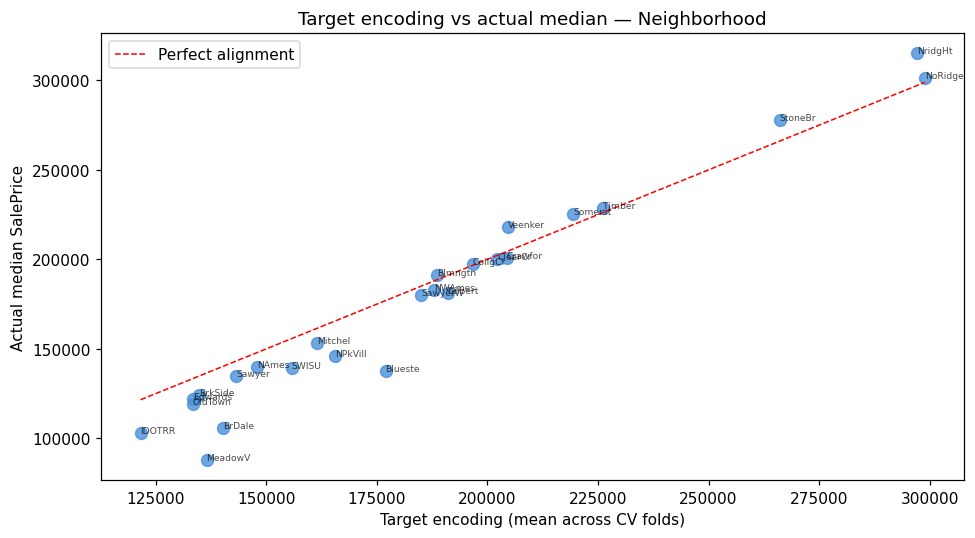

In [11]:
# Visualise: encoded value vs actual median sale price per neighbourhood
neighborhood_median = df_enc.groupby('Neighborhood')['SalePrice'].median()
neighborhood_te_mean = df_enc.groupby('Neighborhood')['neighborhood_te'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(neighborhood_te_mean, neighborhood_median, alpha=0.8, s=60, color='#4a90d9')
for nb in neighborhood_median.index:
    ax.annotate(nb, (neighborhood_te_mean[nb], neighborhood_median[nb]),
                fontsize=6, alpha=0.7)
ax.set_xlabel('Target encoding (mean across CV folds)')
ax.set_ylabel('Actual median SalePrice')
ax.set_title('Target encoding vs actual median — Neighborhood')
ax.plot([neighborhood_te_mean.min(), neighborhood_te_mean.max()],
        [neighborhood_te_mean.min(), neighborhood_te_mean.max()],
        'r--', linewidth=1, label='Perfect alignment')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 4 — Frequency Encoding

Frequency encoding replaces each category with its **count or proportion** in the dataset. It captures how common a category is, which can itself be informative.

**Use when:**
- High cardinality and no target is available (unsupervised context)
- Frequency of occurrence is itself a meaningful signal (e.g. rare product categories)

**Limitation:** Two categories with the same frequency get the same code — the encoding loses the distinction between them.

In [12]:
# Frequency encoding: proportion of each category in the dataset
freq_map = df['Neighborhood'].value_counts(normalize=True)
df['neighborhood_freq'] = df['Neighborhood'].map(freq_map)

print('Frequency encoding — Neighborhood (top 10):')
print(freq_map.head(10).to_string())

Frequency encoding — Neighborhood (top 10):
Neighborhood
NAmes      0.154110
CollgCr    0.102740
OldTown    0.077397
Edwards    0.068493
Somerst    0.058904
Gilbert    0.054110
NridgHt    0.052740
Sawyer     0.050685
NWAmes     0.050000
SawyerW    0.040411


---
## Section 5 — Comparison and Leakage Prevention

Encoding strategy affects model performance. We compare ordinal vs OHE vs target encoding in a fair cross-validated benchmark, taking care to prevent leakage by encoding inside the CV loop.

In [13]:
# Prepare a clean modelling subset
feature_cols = ['OverallQual', 'GrLivArea', 'ExterQual', 'KitchenQual', 'Neighborhood']
target_col = 'SalePrice'

df_model = df[feature_cols + [target_col]].dropna().reset_index(drop=True)
X = df_model[feature_cols]
y = np.log1p(df_model[target_col])  # log-transform target for normality

print(f'Modelling dataset: {X.shape}')

# Train/test split (all encoding happens on train only)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Modelling dataset: (1460, 5)


In [14]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error

# --- Pipeline A: Ordinal for quality cols + OHE for Neighborhood ---
pipe_ohe = Pipeline([
    ('pre', ColumnTransformer([
        ('num',  'passthrough',  ['OverallQual', 'GrLivArea']),
        ('qual', OrdinalEncoder(categories=[quality_order, quality_order],
                                handle_unknown='use_encoded_value', unknown_value=-1),
                ['ExterQual', 'KitchenQual']),
        ('ohe',  OneHotEncoder(handle_unknown='ignore', sparse_output=False),
                ['Neighborhood']),
    ])),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42)),
])

scores_ohe = cross_val_score(pipe_ohe, X_train, y_train, cv=5, scoring='r2')
print(f'OHE pipeline   — CV R²: {scores_ohe.mean():.4f} ± {scores_ohe.std():.4f}')

OHE pipeline   — CV R²: 0.7820 ± 0.0236


In [15]:
# --- Pipeline B: Ordinal for quality + frequency encoding for Neighborhood ---
# Frequency encoding: compute map on train fold only (no leakage)

from sklearn.base import BaseEstimator, TransformerMixin

class FreqEncoder(BaseEstimator, TransformerMixin):
    """Encodes each category as its proportion in the training data.
    Inherits from BaseEstimator/TransformerMixin so sklearn can clone and
    compose it inside ColumnTransformer / cross_val_score.
    Uses np.asarray() to handle both DataFrame and numpy array inputs
    (sklearn 1.2+ passes DataFrames through when set_output API is active).
    """
    def fit(self, X, y=None):
        s = pd.Series(np.asarray(X).ravel())
        self.map_ = s.value_counts(normalize=True).to_dict()
        self.default_ = 1 / max(s.nunique(), 1)
        return self

    def transform(self, X):
        s = pd.Series(np.asarray(X).ravel())
        return s.map(self.map_).fillna(self.default_).values.reshape(-1, 1)

pipe_freq = Pipeline([
    ('pre', ColumnTransformer([
        ('num',  'passthrough',  ['OverallQual', 'GrLivArea']),
        ('qual', OrdinalEncoder(categories=[quality_order, quality_order],
                                handle_unknown='use_encoded_value', unknown_value=-1),
                ['ExterQual', 'KitchenQual']),
        ('freq', FreqEncoder(), ['Neighborhood']),
    ])),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42)),
])

scores_freq = cross_val_score(pipe_freq, X_train, y_train, cv=5, scoring='r2')
print(f'Freq pipeline  — CV R²: {scores_freq.mean():.4f} ± {scores_freq.std():.4f}')

Freq pipeline  — CV R²: 0.7645 ± 0.0234


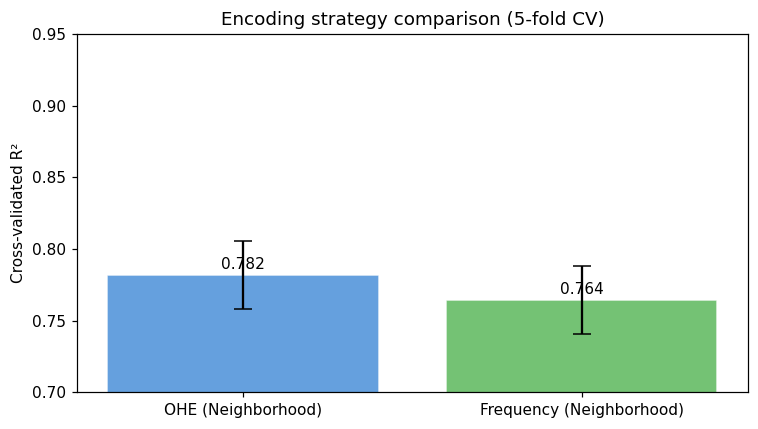

In [16]:
# Summary comparison
fig, ax = plt.subplots(figsize=(7, 4))

names  = ['OHE (Neighborhood)', 'Frequency (Neighborhood)']
means  = [scores_ohe.mean(), scores_freq.mean()]
stds   = [scores_ohe.std(),  scores_freq.std()]

bars = ax.bar(names, means, yerr=stds, capsize=6,
              color=['#4a90d9', '#5cb85c'], edgecolor='white', alpha=0.85)
ax.set_ylabel('Cross-validated R²')
ax.set_title('Encoding strategy comparison (5-fold CV)')
ax.set_ylim(0.7, 0.95)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{m:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## Key Takeaways

1. **Match the encoder to the column's nature** — ordinal for ordered; OHE for nominal low-cardinality; target/frequency for high-cardinality.
2. **Ordinal encoding on nominal columns is wrong** — it imposes an arbitrary distance relationship the algorithm will learn to exploit incorrectly.
3. **OHE explodes features** at high cardinality — 100 unique cities → 100 binary columns, most nearly empty.
4. **Target encoding leaks if fit on full data** — always compute category statistics inside each CV fold or on training data only.
5. **Smoothing prevents rare-category overfitting** — categories seen once should trust the global mean, not their single observed value.
6. **Always use a Pipeline** — it ensures encoders are fit on training data and applied consistently to validation and test data.

---
## Exercises

1. Load `seaborn.load_dataset('tips')`. Apply OHE to `sex`, `smoker`, and `day`. How many columns does `time` add with and without `drop='first'`?
2. Apply ordinal encoding to `size` (treating it as ordered 1–6). Compare R² of a linear regression predicting `tip` with ordinal vs OHE encoding for `size`.
3. Manually verify that the cross-fold target encoder does not use any target values from the validation fold during encoding (add a print statement inside the loop to inspect the fold sizes).
4. What happens to `handle_unknown='ignore'` in OHE when the test set contains a category not seen during training? Demonstrate this with a toy example.

In [19]:
# ========== Setup ==========
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
import warnings
warnings.filterwarnings('ignore')

# ========== Load tips dataset from local file ==========
file_path = r'C:\Users\35111\Downloads\OneDrive_1_2026-5-26\tips.csv'
tips = pd.read_csv(file_path)
print("Tips dataset loaded from local file.")
print("Shape:", tips.shape)
print("First 5 rows:")
print(tips.head())

# ========== Exercise 1: OHE on sex, smoker, day; compare time with/without drop='first' ==========
print("\n" + "="*60)
print("Exercise 1: OHE on sex, smoker, day; and time column with/without drop='first'")
print("="*60)

# OHE for sex, smoker, day (no drop)
ohe_full = OneHotEncoder(drop=None, sparse_output=False)
encoded_full = ohe_full.fit_transform(tips[['sex', 'smoker', 'day']])
print(f"Columns after OHE (sex, smoker, day) with drop=None: {encoded_full.shape[1]}")

# OHE for sex, smoker, day with drop='first'
ohe_drop = OneHotEncoder(drop='first', sparse_output=False)
encoded_drop = ohe_drop.fit_transform(tips[['sex', 'smoker', 'day']])
print(f"Columns after OHE (sex, smoker, day) with drop='first': {encoded_drop.shape[1]}")

# Now check how many columns 'time' adds with/without drop='first'
ohe_time_full = OneHotEncoder(drop=None, sparse_output=False)
time_full = ohe_time_full.fit_transform(tips[['time']])
print(f"Columns added by 'time' with drop=None: {time_full.shape[1]}")

ohe_time_drop = OneHotEncoder(drop='first', sparse_output=False)
time_drop = ohe_time_drop.fit_transform(tips[['time']])
print(f"Columns added by 'time' with drop='first': {time_drop.shape[1]}")

# ========== Exercise 2: Ordinal vs OHE encoding for 'size' (ordered 1-6) ==========
print("\n" + "="*60)
print("Exercise 2: Ordinal vs OHE encoding for 'size' (1-6), predict tip using LinearRegression")
print("="*60)

# Prepare data
X = tips[['size']].copy()
y = tips['tip']

# Ordinal encoding (ordered categories)
ordinal_enc = OrdinalEncoder(categories=[[1,2,3,4,5,6]])  # preserve order
X_ordinal = ordinal_enc.fit_transform(X)

# One-hot encoding
ohe = OneHotEncoder(sparse_output=False)
X_ohe = ohe.fit_transform(X)

# Linear regression models
model_ord = LinearRegression()
model_ohe = LinearRegression()

cv_scores_ord = cross_val_score(model_ord, X_ordinal, y, cv=5, scoring='r2')
cv_scores_ohe = cross_val_score(model_ohe, X_ohe, y, cv=5, scoring='r2')

print(f"Ordinal encoding R² (mean ± std): {cv_scores_ord.mean():.4f} ± {cv_scores_ord.std():.4f}")
print(f"One-hot encoding R² (mean ± std): {cv_scores_ohe.mean():.4f} ± {cv_scores_ohe.std():.4f}")

# ========== Exercise 3: Manual verification of cross‑fold target encoder ==========
print("\n" + "="*60)
print("Exercise 3: Cross‑fold target encoder – verify no target leakage")
print("="*60)

def cross_fold_target_encoder(X, y, col, n_splits=5, random_state=42):
    """
    Simple target encoder using KFold.
    Prints fold sizes to verify that validation target is not used in encoding.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    encoded = pd.Series(index=X.index, dtype=float)
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"Fold {fold+1}: train size = {len(train_idx)}, val size = {len(val_idx)}")
        # Compute category means from training fold only
        train_data = X.iloc[train_idx]
        train_target = y.iloc[train_idx]
        # Important: use the column name (y.name) instead of the Series directly
        category_means = train_data.groupby(col)[y.name].mean()
        # Apply to validation fold
        encoded.iloc[val_idx] = X.iloc[val_idx][col].map(category_means)
    
    return encoded

# Use a subset for demonstration
df_demo = tips[['day', 'tip']].copy()
encoded_target = cross_fold_target_encoder(df_demo, df_demo['tip'], col='day')
print("Target encoding completed. Validation targets never used in computing category means within each fold.")

# ========== Exercise 4: handle_unknown='ignore' behavior with unseen categories ==========
print("\n" + "="*60)
print("Exercise 4: OneHotEncoder with handle_unknown='ignore' on test set with new category")
print("="*60)

# Toy example
train_data = pd.DataFrame({'color': ['red', 'blue', 'red', 'blue']})
test_data = pd.DataFrame({'color': ['red', 'green', 'blue']})  # 'green' unseen

ohe_ignore = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_ignore.fit(train_data[['color']])
train_encoded = ohe_ignore.transform(train_data[['color']])
test_encoded = ohe_ignore.transform(test_data[['color']])

print("Training categories:", ohe_ignore.categories_)
print("Test data before encoding:")
print(test_data)
print("Test data after encoding (unseen category becomes all zeros):")
print(test_encoded)
print("Explanation: 'green' is not in training categories, so its row becomes [0, 0].")

Tips dataset loaded from local file.
Shape: (244, 7)
First 5 rows:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Exercise 1: OHE on sex, smoker, day; and time column with/without drop='first'
Columns after OHE (sex, smoker, day) with drop=None: 8
Columns after OHE (sex, smoker, day) with drop='first': 5
Columns added by 'time' with drop=None: 2
Columns added by 'time' with drop='first': 1

Exercise 2: Ordinal vs OHE encoding for 'size' (1-6), predict tip using LinearRegression
Ordinal encoding R² (mean ± std): 0.2305 ± 0.1211
One-hot encoding R² (mean ± std): 0.2016 ± 0.1303

Exercise 3: Cross‑fold target encoder – verify no target leakage
Fold 1: train size = 195, val size = 49
Fold 2: train size = 195, val siz